In [51]:
import matplotlib.pyplot as plt
from colossus.cosmology import cosmology
import numpy as np
from scipy.optimize import minimize

# Initialize cosmology using Colossus
cosmo_params = {
    'flat': False,
    'H0': 70.0,  
    'Om0': 0.3,
    'Ob0': 0.048,
    'Ode0': 0.75,
    'sigma8': 0.8102,
    'ns': 0.964
}
cosmology.addCosmology('customCosmo', cosmo_params)
cosmo = cosmology.setCosmology('customCosmo')

# Load SCP Union 2.1 dataset
union21 = np.loadtxt(
    'SCPUnion2.1_mu_vs_z.txt',
    dtype={'names': ('name', 'z', 'mu', 'mu_error', 'XXX'),
           'formats': ('S6', 'f', 'f', 'f', 'f')}
)

# Likelihood function
def lhood_sne_colossus(om, ol, h):
    # Update cosmology with parameters
    local_params = cosmo_params.copy()
    local_params['Om0'] = om
    local_params['Ode0'] = ol
    local_params['H0'] = 100*h
    cosmo = cosmology.setCosmology('localCosmo', local_params)
    mu_teo = cosmo.distanceModulus(union21['z'])
    chiq = ((mu_teo - union21['mu']) / union21['mu_error']) ** 2
    chiq = chiq.sum() - chiq.size
    return np.exp(-0.5 * chiq)

# Residual function for minimization
def residual_colossus(p):
    res = -2 * np.log(lhood_sne_colossus(p[0], p[1], p[2]))
    if np.isnan(res):
        return np.inf
    else:
        return res

# Likelihood function for emcee sampling
def lnprob_colossus(p):
    try:
        return lhood_sne_colossus(p[0], p[1], p[2])
    except:
        return 0

In [66]:
# Initial guesses for parameters
initial_params = [0.3, 0.75, 0.7]  # Omega_m, Omega_Lambda, h

# Bounds for parameters
bounds = [(0.1, 0.5), (0.3, 1.0), (0.5, 0.9)]
result = minimize(
        residual_colossus, initial_params, method='Nelder-Mead'
    )
best_fit_params = result.x
print(result)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -17.79661517187924
             x: [ 2.787e-01  7.262e-01  7.002e-01]
           nit: 51
          nfev: 95
 final_simplex: (array([[ 2.787e-01,  7.262e-01,  7.002e-01],
                       [ 2.786e-01,  7.261e-01,  7.002e-01],
                       [ 2.787e-01,  7.262e-01,  7.002e-01],
                       [ 2.787e-01,  7.262e-01,  7.003e-01]]), array([-1.780e+01, -1.780e+01, -1.780e+01, -1.780e+01]))


In [54]:
best_fit = cosmo_params.copy()
best_fit['Om0'] = best_fit_params[0]
best_fit['Ode0'] = best_fit_params[1]
best_fit['H0'] = 100*best_fit_params[2]
cosmology.addCosmology('bestCosmo', best_fit)
cosmo = cosmology.setCosmology('bestCosmo')

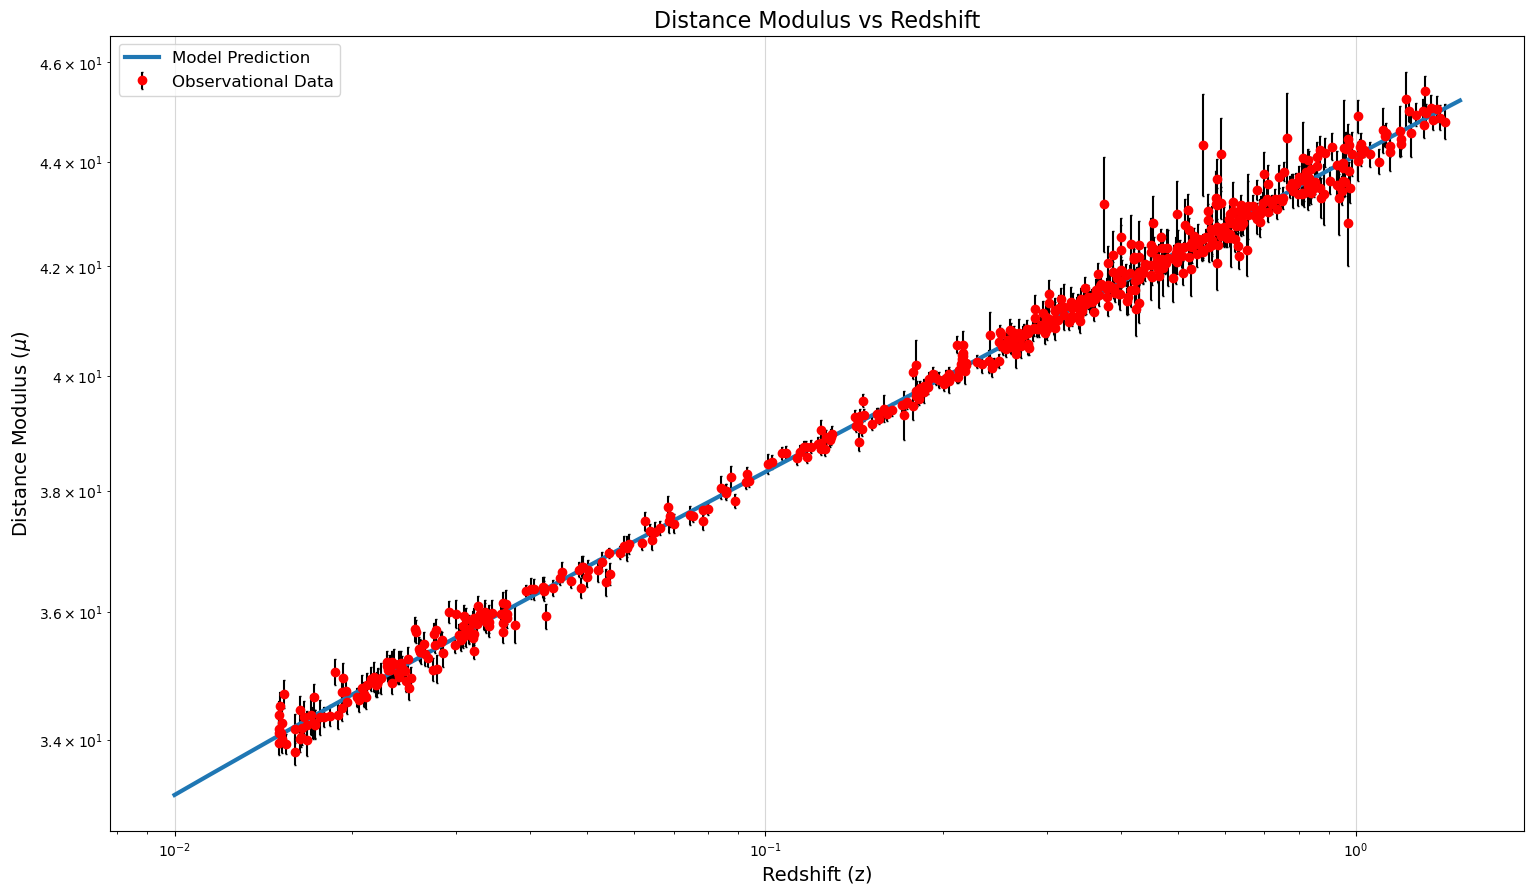

In [65]:
plt.figure(figsize=(15, 9))
zplot = np.linspace(0.01, 1.5, 1000)
plt.errorbar(union21['z'], union21['mu'], yerr=union21['mu_error'],
             fmt='o', label='Observational Data', color='red', ecolor='black', capsize=1)
plt.xlabel('Redshift (z)', fontsize=14)
plt.ylabel('Distance Modulus ($\mu$)', fontsize=14)
plt.title('Distance Modulus vs Redshift', fontsize=16)
plt.plot(zplot, cosmo.distanceModulus(zplot), label='Model Prediction', linewidth=3)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.tight_layout()
plt.loglog()
plt.show()